In [1]:
import os
# Hide GPU to run cleanly on CPU
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import h5py
import numpy as np
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Devices Available:", tf.config.list_physical_devices())

2026-07-21 09:47:59.242080: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-21 09:47:59.242220: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-21 09:47:59.508657: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.15.1
Devices Available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


2026-07-21 09:48:16.259557: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [8]:
import h5py
import numpy as np
import gc

def load_and_filter_2gb_budget(h5_path, x_key, y_key, min_hits=5, chunk_size=2000):
    x_chunks = []
    y_chunks = []
    
    with h5py.File(h5_path, 'r') as f:
        y_raw = f[y_key][:].flatten()
        total_samples = len(y_raw)
        x_ds = f[x_key]
        
        for i in range(0, total_samples, chunk_size):
            x_chunk = x_ds[i : i + chunk_size]
            y_chunk = y_raw[i : i + chunk_size]
            
            n_hits = np.count_nonzero(x_chunk, axis=(1, 2))
            mask = (y_chunk == 0) | ((y_chunk == 1) & (n_hits >= min_hits))
            
            if np.any(mask):
                x_chunks.append(x_chunk[mask].astype(np.uint8))
                y_chunks.append(y_chunk[mask].astype(np.uint8))
            
            del x_chunk, y_chunk, n_hits, mask
            
    X_filtered = np.expand_dims(np.concatenate(x_chunks, axis=0), -1)
    y_filtered = np.concatenate(y_chunks, axis=0)
    
    del x_chunks, y_chunks
    gc.collect()
    
    return X_filtered, y_filtered

In [10]:
X_train, y_train = load_and_filter_2gb_budget('processed_physics_data.h5', 'X_train', 'y_train', min_hits=5)
X_val, y_val = load_and_filter_2gb_budget('processed_physics_data.h5', 'X_val', 'y_val', min_hits=5)

print(f"\n Filtered Training size: {X_train.shape}")
print(f"Filtered Validation size: {X_val.shape}")


 Filtered Training size: (83850, 24, 36, 1)
Filtered Validation size: (20955, 24, 36, 1)


In [11]:
import qkeras
from qkeras.utils import _add_supported_quantized_objects

custom_objects = {}
_add_supported_quantized_objects(custom_objects)
print("QKeras Version:", qkeras.__version__)

QKeras Version: 0.9.0


In [12]:
from tensorflow.keras.layers import Input, BatchNormalization, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Model
from qkeras import QConv2D, QActivation, QDense, quantized_bits

W_Q = quantized_bits(16, 6, alpha=1)
A_Q = "quantized_relu(16,6)"

In [13]:
inputs = Input(shape=(24, 36, 1))
x = QConv2D(12, kernel_size=(3, 3), padding="same", kernel_quantizer=W_Q, use_bias=False, name="qconv_1")(inputs)
x = BatchNormalization()(x)
x = QActivation(A_Q, name="qact_1")(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

In [14]:
x = QConv2D(24, kernel_size=(3, 3), padding="same", kernel_quantizer=W_Q, use_bias=False, name="qconv_2")(x)
x = BatchNormalization()(x)
x = QActivation(A_Q, name="qact_2")(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

In [15]:
x = Flatten()(x)
x = QDense(12, kernel_quantizer=W_Q, use_bias=False, name="qdense_1")(x)
x = BatchNormalization()(x)
x = QActivation(A_Q, name="qact_3")(x)
x = Dropout(0.2)(x)

In [16]:
outputs = QDense(1, activation="sigmoid", kernel_quantizer=W_Q, use_bias=False, name="qoutput")(x)

model = Model(inputs=inputs, outputs=outputs, name="Optimized_AUC_Micro_QNet")
model.summary()

Model: "Optimized_AUC_Micro_QNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 36, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 24, 36, 12)     │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 36, 12)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qact_1 (QActivation)            │ (None, 24, 36, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 18, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 12, 18, 24)     │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 18, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qact_2 (QActivation)            │ (None, 12, 18, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 9, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1296)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 12)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qact_3 (QActivation)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qoutput (QDense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,456 (72.09 KB)

 Trainable params: 18,360 (71.72 KB)

 Non-trainable params: 96 (384.00 B)

In [22]:
import tensorflow as tf

tf.config.run_functions_eagerly(True)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    run_eagerly=True  
)


In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [24]:

early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [25]:

reduce_lr = ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=1
)

In [26]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/100


/opt/conda/envs/hls4ml/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


  1/656 ━━━━━━━━━━━━━━━━━━━━ 14:42 1s/step - accuracy: 0.7891 - auc: 0.1987 - loss: 0.7606

/home/nahom338/.local/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['qconv_1/kernel', 'qconv_2/kernel', 'qdense_1/kernel', 'qoutput/kernel'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8556 - auc: 0.3136 - loss: 0.4951
Epoch 1: val_auc improved from None to 0.57743, saving model to best_model.keras
656/656 ━━━━━━━━━━━━━━━━━━━━ 43s 64ms/step - accuracy: 0.9014 - auc: 0.3663 - loss: 0.4083 - val_accuracy: 0.9501 - val_auc: 0.5774 - val_loss: 0.2437 - learning_rate: 0.0010
Epoch 2/100
655/656 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9467 - auc: 0.6207 - loss: 0.2348
Epoch 2: val_auc improved from 0.57743 to 0.85554, saving model to best_model.keras
656/656 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.9484 - auc: 0.6873 - loss: 0.2085 - val_accuracy: 0.9553 - val_auc: 0.8555 - val_loss: 0.1496 - learning_rate: 0.0010
Epoch 3/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9529 - auc: 0.7965 - loss: 0.1659
Epoch 3: val_auc improved from 0.85554 to 0.91429, saving model to best_model.keras
656/656 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - accuracy: 0.9519 - auc: 0.8175 - loss: 0.1616 - val_accuracy: 

655/656 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9565 - auc: 0.9478 - loss: 0.1093
Epoch 39: val_auc did not improve from 0.96927
656/656 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.9562 - auc: 0.9487 - loss: 0.1098 - val_accuracy: 0.9598 - val_auc: 0.9693 - val_loss: 0.0940 - learning_rate: 2.5000e-04
Epoch 40/100
655/656 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9546 - auc: 0.9494 - loss: 0.1119
Epoch 40: val_auc did not improve from 0.96927
656/656 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.9558 - auc: 0.9494 - loss: 0.1097 - val_accuracy: 0.9596 - val_auc: 0.9691 - val_loss: 0.0939 - learning_rate: 2.5000e-04
Epoch 41/100
655/656 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9554 - auc: 0.9513 - loss: 0.1085
Epoch 41: val_auc did not improve from 0.96927

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
656/656 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.9555 - auc: 0.9491 - loss: 0.1098 - val_accuracy: 0.9599 - val_auc: 0.

In [29]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
y_pred = model.predict(X_val, batch_size=256).ravel()
y_true = y_val.ravel()
exact_auc = roc_auc_score(y_true, y_pred)


print(f" VAL AUC: {exact_auc:.4f} ({exact_auc*100:.2f}%)")

 3/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step

/opt/conda/envs/hls4ml/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
 VAL AUC: 0.9694 (96.94%)


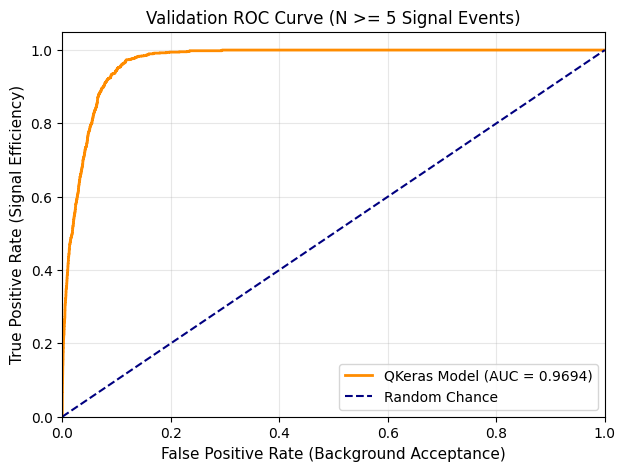

In [30]:
fpr, tpr, _ = roc_curve(y_true, y_pred)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'QKeras Model (AUC = {exact_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Acceptance)', fontsize=11)
plt.ylabel('True Positive Rate (Signal Efficiency)', fontsize=11)
plt.title('Validation ROC Curve (N >= 5 Signal Events)', fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Load The Best Keras Model 

In [31]:
import tensorflow as tf
import qkeras
from qkeras.utils import _add_supported_quantized_objects
custom_objects = {}
_add_supported_quantized_objects(custom_objects)

model_path = "best_model.keras"
model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)

print("Success! Original Model Loaded.")
model.summary()

Success! Original Model Loaded.


Model: "Optimized_AUC_Micro_QNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 36, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 24, 36, 12)     │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 36, 12)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qact_1 (QActivation)            │ (None, 24, 36, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 18, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 12, 18, 24)     │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 18, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qact_2 (QActivation)            │ (None, 12, 18, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 9, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1296)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 12)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qact_3 (QActivation)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qoutput (QDense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,178 (215.54 KB)

 Trainable params: 18,360 (71.72 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 36,722 (143.45 KB)

In [32]:
from qkeras import QConv2D, QDense

trainable_layers = [l for l in model.layers if isinstance(l, (QConv2D, QDense))]

print(f"Found {len(trainable_layers)} prunable layers in the architecture!\n")
for i, layer in enumerate(trainable_layers):
    weights = layer.get_weights()
    if weights:
        print(f"Layer {i}: {layer.name} | Weights shape: {weights[0].shape}")

Found 4 prunable layers in the architecture!

Layer 0: qconv_1 | Weights shape: (3, 3, 1, 12)
Layer 1: qconv_2 | Weights shape: (3, 3, 12, 24)
Layer 2: qdense_1 | Weights shape: (1296, 12)
Layer 3: qoutput | Weights shape: (12, 1)


# Pruning 

In [34]:
import numpy as np
target_sparsity = 10

for layer in trainable_layers:
    weights = layer.get_weights()
    if not weights:
        continue
    
    kernel = weights[0]
    threshold = np.percentile(np.abs(kernel), target_sparsity)
    mask = np.abs(kernel) >= threshold
    pruned_kernel = kernel * mask
    
    weights[0] = pruned_kernel
    layer.set_weights(weights)

print(f"Success! {target_sparsity}% of the weights in all QConv2D and QDense layers have been zeroed out.")

Success! 10% of the weights in all QConv2D and QDense layers have been zeroed out.


In [35]:
total_weights = 0
zero_weights = 0

for layer in trainable_layers:
    weights = layer.get_weights()
    if weights:
        kernel = weights[0]
        total_weights += kernel.size
        zero_weights += np.sum(kernel == 0)

sparsity = (zero_weights / total_weights) * 100
print(f"Total parameters checked: {total_weights:,}")
print(f"Zeroed-out parameters: {zero_weights:,}")
print(f"Overall Sparsity: {sparsity:.2f}% (Target was {target_sparsity:.2f}%)")

Total parameters checked: 18,264
Zeroed-out parameters: 1,829
Overall Sparsity: 10.01% (Target was 10.00%)


In [36]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

pruned_save_path = "best_model_pruned_10pct.keras"
model.save(pruned_save_path)
print(f"Success! Pruned model saved to: {pruned_save_path}")

Success! Pruned model saved to: best_model_pruned_10pct.keras


In [37]:
from sklearn.metrics import roc_auc_score
y_pred = model.predict(X_val, batch_size=256).ravel()
y_true = y_val.ravel()

pruned_auc = roc_auc_score(y_true, y_pred)
pruned_acc = np.mean((y_pred >= 0.5).astype(int) == y_true) * 100

print(f" Pruned Model Accuracy : {pruned_acc:.2f}%")
print(f" Pruned Model AUC      : {pruned_auc:.4f}")

 6/82 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

/opt/conda/envs/hls4ml/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
 Pruned Model Accuracy : 95.94%
 Pruned Model AUC      : 0.9685


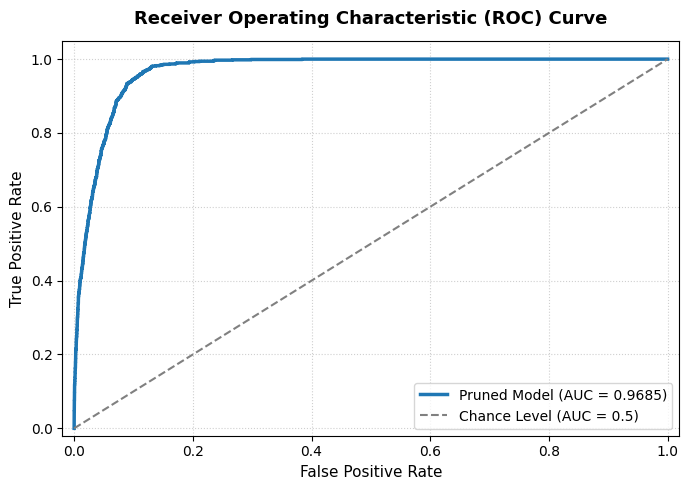

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Pruned Model (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Chance Level (AUC = 0.5)')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold', pad=12)
plt.legend(loc="lower right", frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# HLS4ML CONFIG